In [3]:
# J'importe les librairies dont j'ai besoin
import pandas as pd          # Pandas sert à lire et manipuler mes données
import numpy as np            # Numpy sert pour les calculs numériques
import matplotlib.pyplot as plt  # Matplotlib sert à faire des graphiques
import seaborn as sns          # Seaborn sert aussi à faire des graphiques, plus jolis
from scipy.stats import pearsonr  # J'importe un test statistique (Pearson)
import os                      # Os sert à gérer les fichiers et dossiers

# Je vérifie que tout est bien importé
print("All libraries imported!")


All libraries imported!


>  **Interprétation :**
> Je commence mon projet. J'importe les outils Python nécessaires pour lire, nettoyer et visualiser mes données.

## PARTIE 1

In [56]:
df = pd.read_csv('../data/clean/rekrute_text_mining_master_obt.csv')

> 🎤 **Interprétation pour le jury :**
> Je charge mon fichier de données. C'est le point de départ de mon analyse.

In [5]:
# Affiche les 'n' premières lignes (par défaut 5)
df.head()

,offer_id,scrape_date,scrape_timestamp,titre_poste,entreprise,secteur_entreprise,taille_entreprise,ville,ville_normalized,region,...,has_salary_info,site_web_entreprise,url,date_annee,job_id,llm_salary_min_mad,llm_salary_max_mad,is_agile_driven,has_corp_perks,is_remote_friendly
0,846932618F,2026-06-16,2026-06-16T14:05:33.422004,Project Management Office (PMO),Atos,Gestion projet / Etudes / R&D- Informatique / ...,NaN,Casablanca,Casablanca,Casablanca-Settat,...,0,NaN,https://www.rekrute.com/offre-emploi-project-m...,2016,846932618F,NaN,NaN,False,False,False
1,35C4397FD9,2026-06-16,2026-06-16T14:05:33.740498,Stage en coordination mobilité internationale,Atos,Informatique,NaN,Casablanca,Casablanca,Casablanca-Settat,...,0,NaN,https://www.rekrute.com/offre-emploi-stage-en-...,2016,35C4397FD9,NaN,NaN,False,False,False
2,D3E682961F,2026-06-16,2026-06-16T14:05:33.890840,Chefs de Projets Techniques .NET,Sqli Maroc,Informatique / Electronique- Internet / Multim...,NaN,Rabat,Rabat,Rabat-Salé-Kénitra,...,0,NaN,https://www.rekrute.com/offre-emploi-chefs-de-...,2016,D3E682961F,NaN,NaN,False,False,False
3,3982EE759A,2026-06-16,2026-06-16T14:05:34.188578,Développeur Front End Angular JS en CDI,Welink,Informatique / Electronique- Internet / Multim...,NaN,Rabat,Rabat,Rabat-Salé-Kénitra,...,0,NaN,https://www.rekrute.com/offre-emploi-developpe...,2016,3982EE759A,NaN,NaN,False,False,False
4,2370F10D20,2026-06-16,2026-06-16T14:05:34.869485,Développeur Front End Angular JS en CDI,Welink,Informatique / Electronique- Internet / Multim...,NaN,Rabat,Rabat,Rabat-Salé-Kénitra,...,0,NaN,https://www.rekrute.com/offre-emploi-developpe...,2016,2370F10D20,NaN,NaN,False,False,False


> 🎤 **Interprétation pour le jury :**
> Le problème est de savoir si mes données sont correctes. J'affiche les premières lignes pour vérifier. Le résultat montre des offres d'emploi IT au Maroc, avec des entreprises comme Atos et Sqli.

In [6]:
# Renvoie le nombre de lignes et de colonnes
df.shape

(10782, 45)

> 🎤 **Interprétation :**
> Je veux connaître la taille de mon dataset. Je vérifie le nombre de lignes et de colonnes. Le résultat est 10 782 offres et 45 colonnes, ce qui est suffisant pour une analyse fiable.

In [49]:
# J'affiche le nom de toutes les colonnes
df.columns

Index(['offer_id', 'scrape_date', 'scrape_timestamp', 'titre_poste',
       'entreprise', 'secteur_entreprise', 'taille_entreprise', 'ville',
       'ville_normalized', 'region', 'type_contrat', 'type_contrat_normalized',
       'modalite_travail', 'is_remote', 'is_hybrid', 'is_onsite',
       'niveau_etudes', 'niveau_etudes_normalized', 'experience_requise',
       'experience_years_min', 'experience_years_max', 'langue',
       'secteur_activite', 'sous_secteur', 'fonction', 'sous_fonction',
       'hard_skills', 'soft_skills', 'tech_stack', 'tech_count',
       'soft_skills_count', 'nbr_postes', 'date_publication', 'date_limite',
       'salaire', 'has_salary_info', 'site_web_entreprise', 'url',
       'date_annee', 'job_id', 'llm_salary_min_mad', 'llm_salary_max_mad',
       'is_agile_driven', 'has_corp_perks', 'is_remote_friendly'],
      dtype='str')

> 🎤 **Interprétation pour le jury :**
> Je veux connaître le contenu de mon dataset. J'affiche la liste des colonnes. Je vois des informations utiles comme la ville, la technologie et le télétravail.

In [50]:
# J'affiche le type de chaque colonne (texte, nombre, etc.)
df.dtypes

offer_id                        str
scrape_date                     str
scrape_timestamp                str
titre_poste                     str
entreprise                      str
secteur_entreprise              str
taille_entreprise           float64
ville                           str
ville_normalized                str
region                          str
type_contrat                    str
type_contrat_normalized         str
modalite_travail                str
is_remote                     int64
is_hybrid                     int64
is_onsite                     int64
niveau_etudes                   str
niveau_etudes_normalized        str
experience_requise              str
experience_years_min          int64
experience_years_max          int64
langue                          str
secteur_activite                str
sous_secteur                    str
fonction                        str
sous_fonction               float64
hard_skills                     str
soft_skills                 

> 🎤 **Interprétation pour le jury :**
> Je vérifie le type de chaque colonne. Je remarque un problème : la colonne salaire a très peu de valeurs remplies. Le salaire est donc caché dans presque toutes les offres.

In [9]:
# Résumé technique complet du DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10782 entries, 0 to 10781
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   offer_id                  10782 non-null  str    
 1   scrape_date               10782 non-null  str    
 2   scrape_timestamp          10782 non-null  str    
 3   titre_poste               10782 non-null  str    
 4   entreprise                10782 non-null  str    
 5   secteur_entreprise        10782 non-null  str    
 6   taille_entreprise         0 non-null      float64
 7   ville                     10782 non-null  str    
 8   ville_normalized          10782 non-null  str    
 9   region                    9975 non-null   str    
 10  type_contrat              10768 non-null  str    
 11  type_contrat_normalized   10768 non-null  str    
 12  modalite_travail          10782 non-null  str    
 13  is_remote                 10782 non-null  int64  
 14  is_hybrid        

> 🎤 **Interprétation pour le jury :**
> Je fais un contrôle général de la qualité de mes données. Ce résumé me montre les colonnes presque vides. Cela m'aide à savoir quoi nettoyer ensuite.

## 2. Diagnostic de Qualité & Nettoyage

In [10]:
# Compte le nombre total de lignes doublons
df.duplicated().sum()

np.int64(0)

> 🎤 **Interprétation pour le jury :**
> Je vérifie s'il y a des offres en double dans mon dataset. Le résultat est 0. Mes données sont donc uniques, sans doublons.

In [12]:
# 1. Diagnostic
df[['tech_stack', 'langue']].isna().sum()

tech_stack    3206
langue        5805
dtype: int64

In [13]:
# 2. Traitement
df[['tech_stack', 'langue']] = df[['tech_stack', 'langue']].fillna('Non spécifié')

In [14]:
# 3. Vérification
df[['tech_stack', 'langue']].isna().sum()

tech_stack    0
langue        0
dtype: int64

> 🎤 **Interprétation pour le jury :**
> Le problème est que ces colonnes de texte ont des cases vides. J'ai rempli les cases vides avec 'Non spécifié'. Le résultat après vérification est 0 valeur manquante.

In [54]:
# 1. Diagnostic : je compte les valeurs manquantes
df['type_contrat_normalized'].isna().sum()

np.int64(0)

In [53]:
# 2. Traitement : je remplace les vides par la valeur la plus fréquente (le mode)
df['type_contrat_normalized'] = df['type_contrat_normalized'].fillna(df['type_contrat_normalized'].mode()[0])


In [52]:
# 3. Vérification : je vérifie qu'il ne reste plus de valeurs manquantes
df['type_contrat_normalized'].isna().sum()


np.int64(14)

> 🎤 **Interprétation pour le jury :**
> Le problème est qu'un petit nombre d'offres n'a pas de type de contrat. Plutôt que de supprimer ces lignes, j'ai mis la valeur la plus courante. Le résultat garde toutes mes lignes sans perte d'information.

## 🚨 المشكل 3: الأعمدة اللي خاوية 100% (يلا مازال مامسحتيهمش)

In [55]:
# 1. Diagnostic : je vérifie combien de valeurs manquent dans ces colonnes
cols_vides_100 = ['taille_entreprise', 'sous_fonction', 'date_publication']
print(df[cols_vides_100].isna().sum())


taille_entreprise    10782
sous_fonction        10782
date_publication     10782
dtype: int64


In [19]:
# 2. Traitement
df.drop(columns=cols_vides_100, inplace=True)

In [20]:
# 3. Vérification
print("Taille finale du dataset :", df.shape)

Taille finale du dataset : (10782, 42)


Interprétation : Les colonnes structurelles taille_entreprise, sous_fonction et date_publication sont intégralement vides (100% de NaN). Elles ont été supprimées. Notre dataset final est maintenant totalement propre et optimisé pour la phase de Data Visualisation.

## المشكل 1: أعمدة خاوية بـ 94% حتى لـ 99% (الرواتب والمواقع)

In [21]:
# 1. Diagnostic (نشوفو شحال خاويين)
cols_trop_vides = ['salaire', 'llm_salary_min_mad', 'llm_salary_max_mad', 'site_web_entreprise']
print(df[cols_trop_vides].isna().sum())

salaire                10719
llm_salary_min_mad     10693
llm_salary_max_mad     10693
site_web_entreprise    10170
dtype: int64


In [22]:
# 2. Traitement (نمسحوهم)
df.drop(columns=cols_trop_vides, inplace=True)

In [23]:
# 3. Vérification (نتأكدو بلي تمسحو)
print("Ces colonnes existent-elles encore ?", any(col in df.columns for col in cols_trop_vides))

Ces colonnes existent-elles encore ? False


Interprétation : L'outil d'exploration montre que les variables liées aux salaires (salaire, llm_salary_min_mad...) et aux sites web sont manquantes à plus de 94-99%. Conserver ces colonnes ajouterait du bruit inutile à notre dataset. Nous les avons donc supprimées définitivement pour alléger le modèle.

## 🚨 المشكل 2: أعمدة فيها خوى متوسط بين 30% و 57%

In [24]:
# 1. Diagnostic
cols_a_remplir = ['sous_secteur', 'fonction', 'hard_skills']
print(df[cols_a_remplir].isna().sum())

sous_secteur    6168
fonction        6168
hard_skills     3206
dtype: int64


In [25]:
# 2. Traitement
df[cols_a_remplir] = df[cols_a_remplir].fillna('Non spécifié')

In [26]:
# 3. Vérification
print(df[cols_a_remplir].isna().sum())

sous_secteur    0
fonction        0
hard_skills     0
dtype: int64


Interprétation : Plusieurs colonnes descriptives majeures (sous_secteur, fonction, hard_skills) présentaient entre 30% et 57% de valeurs manquantes. Pour préserver les autres informations de ces lignes, nous avons imputé ces vides avec la mention 'Non spécifié'. Le dataset est désormais exempt de valeurs nulles sur ces axes textuels.

In [27]:
# Chargement
df = pd.read_csv('../data/clean/rekrute_text_mining_master_obt.csv')

# === DROP : 22 colonnes identifiées ===
cols_to_drop = [
    # Vides / Constantes
    'taille_entreprise', 'date_publication', 'sous_fonction',
    # Salaire (trop de manquants)
    'salaire', 'llm_salary_min_mad', 'llm_salary_max_mad', 'has_salary_info', 'site_web_entreprise',
    # Constantes (variance = 0)
    'scrape_date', 'is_onsite',
    # Identifiants purs / Haute cardinalité technique
    'scrape_timestamp', 'offer_id', 'url',
    # Redondances parfaites
    'hard_skills',           # identique à tech_stack
    'secteur_entreprise',    # identique à secteur_activite
    'type_contrat',          # identique à type_contrat_normalized
    'ville',                 # ville_normalized est plus propre
    'niveau_etudes',         # 212 vals brutes vs 5 catégories normalized
    # Non pertinent pour nos KPIs
    'nbr_postes',            
    # Colonnes supplémentaires à supprimer
    'soft_skills_count', 
    'tech_count', 
    'date_limite'
]

df_clean = df.drop(columns=cols_to_drop)

# Vérification
print(f"Avant : {df.shape[1]} colonnes  |  Après : {df_clean.shape[1]} colonnes")
print(f"Drop : {len(cols_to_drop)} colonnes supprimées")

# Export
df_clean.to_csv("rekrute_clean_light.csv", index=False)

Avant : 45 colonnes  |  Après : 23 colonnes
Drop : 22 colonnes supprimées


In [28]:
df_clean = pd.read_csv("rekrute_clean_light.csv")

noms_colonnes = {
    'titre_poste': 'job_title',
    'entreprise': 'company_name',
    'ville_normalized': 'city',
    'type_contrat_normalized': 'contract_type',
    'modalite_travail': 'work_mode',
    'is_remote': 'allows_remote',
    'is_hybrid': 'allows_hybrid',
    'niveau_etudes_normalized': 'education_level',
    'experience_requise': 'experience_label',
    'experience_years_min': 'exp_years_min',
    'experience_years_max': 'exp_years_max',
    'langue': 'languages',
    'secteur_activite': 'industry_sector',
    'sous_secteur': 'industry_subsector',
    'fonction': 'job_function',
    'date_annee': 'year',
    'is_agile_driven': 'uses_agile',
    'has_corp_perks': 'has_benefits',
    'is_remote_friendly': 'remote_friendly'
}

df_clean.rename(columns=noms_colonnes, inplace=True)
print("Colonnes renommées avec succès !")
df_clean.to_csv("rekrute_clean_light.csv", index=False)



Colonnes renommées avec succès !


In [29]:
df_clean = pd.read_csv("rekrute_clean_light.csv")
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10782 entries, 0 to 10781
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_title           10782 non-null  str  
 1   company_name        10782 non-null  str  
 2   city                10782 non-null  str  
 3   region              9975 non-null   str  
 4   contract_type       10768 non-null  str  
 5   work_mode           10782 non-null  str  
 6   allows_remote       10782 non-null  int64
 7   allows_hybrid       10782 non-null  int64
 8   education_level     10768 non-null  str  
 9   experience_label    10781 non-null  str  
 10  exp_years_min       10782 non-null  int64
 11  exp_years_max       10782 non-null  int64
 12  languages           4977 non-null   str  
 13  industry_sector     10782 non-null  str  
 14  industry_subsector  4614 non-null   str  
 15  job_function        4614 non-null   str  
 16  soft_skills         10782 non-null  str  
 17  tech

In [30]:
df_clean = pd.read_csv('rekrute_clean_light.csv')

#  1. Languages: NaN → "Non spécifié" 
df_clean['languages'] = df_clean['languages'].fillna('Non spécifié')

#  2. Subsector & Job Function: NaN → "Non catégorisé" 
df_clean['industry_subsector'] = df_clean['industry_subsector'].fillna('Non catégorisé')
df_clean['job_function'] = df_clean['job_function'].fillna('Non catégorisé')

#  3. Tech Stack: NaN → "Non spécifié" 
df_clean['tech_stack'] = df_clean['tech_stack'].fillna('Non spécifié')

#  4. Region (optionnel): NaN → "Non spécifié" 
df_clean['region'] = df_clean['region'].fillna('Non spécifié')

#  5. Education Level: NaN → "Non spécifié" 
df_clean['education_level'] = df_clean['education_level'].fillna('Non spécifié')

# 6. Experience Label: NaN → "Non spécifié" 
df_clean['contract_type'] = df_clean['contract_type'].fillna('Non spécifié')

# Vérification
print(df_clean.info())
df_clean.to_csv('rekrute_clean_final.csv', index=False)

<class 'pandas.DataFrame'>
RangeIndex: 10782 entries, 0 to 10781
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_title           10782 non-null  str  
 1   company_name        10782 non-null  str  
 2   city                10782 non-null  str  
 3   region              10782 non-null  str  
 4   contract_type       10782 non-null  str  
 5   work_mode           10782 non-null  str  
 6   allows_remote       10782 non-null  int64
 7   allows_hybrid       10782 non-null  int64
 8   education_level     10782 non-null  str  
 9   experience_label    10781 non-null  str  
 10  exp_years_min       10782 non-null  int64
 11  exp_years_max       10782 non-null  int64
 12  languages           10782 non-null  str  
 13  industry_sector     10782 non-null  str  
 14  industry_subsector  10782 non-null  str  
 15  job_function        10782 non-null  str  
 16  soft_skills         10782 non-null  str  
 17  tech

In [31]:
df_clean.to_csv("../data/clean/rekrute_clean_light.csv", index=False)
df_clean

,job_title,company_name,city,region,contract_type,work_mode,allows_remote,allows_hybrid,education_level,experience_label,...,industry_sector,industry_subsector,job_function,soft_skills,tech_stack,year,job_id,uses_agile,has_benefits,remote_friendly
0,Project Management Office (PMO),Atos,Casablanca,Casablanca-Settat,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Gestion projet / Etudes / R&D- Informatique / ...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Communication | Implica...,Excel | Vba,2016,846932618F,False,False,False
1,Stage en coordination mobilité internationale,Atos,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac,Débutant (-1 an),...,Informatique,RH / Personnel / Formation,RH / Personnel / Formation,Autonomie | Implication | Management | Recherc...,Non spécifié,2016,35C4397FD9,False,False,False
2,Chefs de Projets Techniques .NET,Sqli Maroc,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+5,Expert (10 à 20 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Esprit d'équipe | Gesti...,.NET | SQL Server | Sql | Ssas | Ssis | Ssrs,2016,D3E682961F,False,False,False
3,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,3982EE759A,False,False,False
4,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,2370F10D20,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10777,Technicien Informatique et Audio-Visuel,Arts Et Metiers Campus De Rabat,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+3,Intermédiaire (3 à 5 ans),...,Caméraman / Monteur / Preneur de son- Informat...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Créativité | Esprit d'é...,Firewall | Linux,2026,481F78014B,False,False,False
10778,Ingénieur Développement Technique & Industrial...,Eni Group Ain Harrouda,Ain Harrouda,Non spécifié,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Autres Industries,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Analyse | Autonomie | Fiabilité | Flexibilité ...,Non spécifié,2026,29DEFD72F1,False,False,False
10779,Ingenieur Méthode assemblage (aéroanutique),Akkodis Maroc,Casablanca,Casablanca-Settat,CDI,Hybride,0,1,Bac+5,Intermédiaire (3 à 5 ans),...,Aéronautique / Spatial,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Organisation | Recherche de nouveauté | Réflexion,Non spécifié,2026,74855578D1,False,False,False
10780,Offre de Stage PFE RH orienté Data Analyst,Capgemini Engineering,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac+5,Débutant (-1 an),...,Automobile / Motos / Cycles,Gestion projet / Etudes / R&D,Gestion projet / Etudes / R&D,Analyse | Autonomie | Créativité | Curiosité |...,Excel | Power BI | Tableau,2026,95C63AB93C,False,False,False


# Partie Visualisations

### Type de variables

1- Variables DISCRÈTES

 NOMINALES Texte SANS ordre
job_title 
company_name 
city
region
contract_type
work_mode
languages
industry_sector
industry_subsector
job_function
soft_skills
tech_stack

ORDINALES Texte AVEC ordre
education_level
experience_label

BINAIRES 0/1 ou False/True
allows_remote
allows_hybrid
uses_agile
has_benefits
remote_friendly

2- Variables CONTINUES 

exp_years_min
exp_years_max
year

In [32]:
df_clean.to_csv("../data/clean/rekrute_clean_light.csv", index=False)
df_clean

,job_title,company_name,city,region,contract_type,work_mode,allows_remote,allows_hybrid,education_level,experience_label,...,industry_sector,industry_subsector,job_function,soft_skills,tech_stack,year,job_id,uses_agile,has_benefits,remote_friendly
0,Project Management Office (PMO),Atos,Casablanca,Casablanca-Settat,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Gestion projet / Etudes / R&D- Informatique / ...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Communication | Implica...,Excel | Vba,2016,846932618F,False,False,False
1,Stage en coordination mobilité internationale,Atos,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac,Débutant (-1 an),...,Informatique,RH / Personnel / Formation,RH / Personnel / Formation,Autonomie | Implication | Management | Recherc...,Non spécifié,2016,35C4397FD9,False,False,False
2,Chefs de Projets Techniques .NET,Sqli Maroc,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+5,Expert (10 à 20 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Esprit d'équipe | Gesti...,.NET | SQL Server | Sql | Ssas | Ssis | Ssrs,2016,D3E682961F,False,False,False
3,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,3982EE759A,False,False,False
4,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,2370F10D20,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10777,Technicien Informatique et Audio-Visuel,Arts Et Metiers Campus De Rabat,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+3,Intermédiaire (3 à 5 ans),...,Caméraman / Monteur / Preneur de son- Informat...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Créativité | Esprit d'é...,Firewall | Linux,2026,481F78014B,False,False,False
10778,Ingénieur Développement Technique & Industrial...,Eni Group Ain Harrouda,Ain Harrouda,Non spécifié,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Autres Industries,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Analyse | Autonomie | Fiabilité | Flexibilité ...,Non spécifié,2026,29DEFD72F1,False,False,False
10779,Ingenieur Méthode assemblage (aéroanutique),Akkodis Maroc,Casablanca,Casablanca-Settat,CDI,Hybride,0,1,Bac+5,Intermédiaire (3 à 5 ans),...,Aéronautique / Spatial,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Organisation | Recherche de nouveauté | Réflexion,Non spécifié,2026,74855578D1,False,False,False
10780,Offre de Stage PFE RH orienté Data Analyst,Capgemini Engineering,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac+5,Débutant (-1 an),...,Automobile / Motos / Cycles,Gestion projet / Etudes / R&D,Gestion projet / Etudes / R&D,Analyse | Autonomie | Créativité | Curiosité |...,Excel | Power BI | Tableau,2026,95C63AB93C,False,False,False


# Analyse Univariée — Discrètes

 contract_type

In [33]:
df_clean["contract_type"].value_counts()

contract_type
CDI             9697
Stage            319
CDD              256
Autre            236
Freelance        235
Intérim           25
Non spécifié      14
Name: count, dtype: int64

<Axes: xlabel='contract_type'>

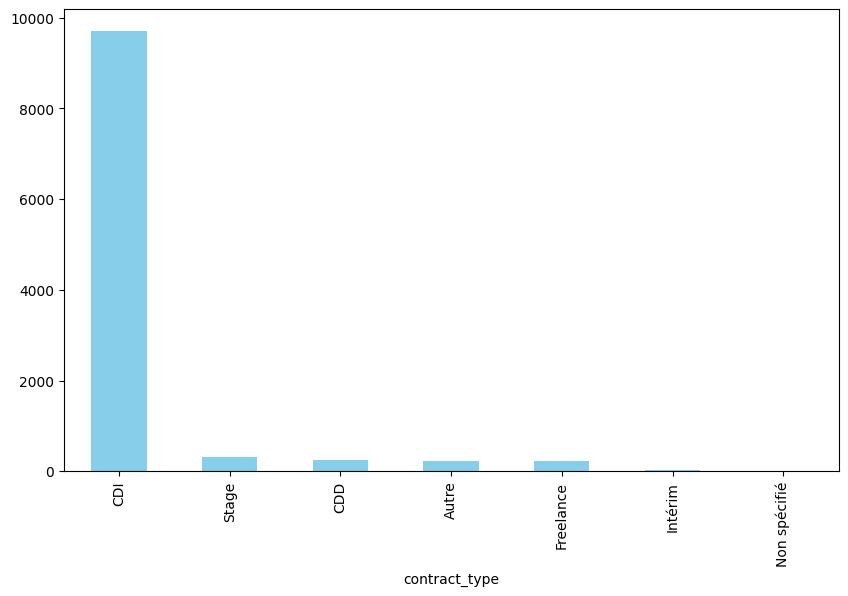

In [34]:
df_clean["contract_type"].value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')

education_level

In [35]:
df_clean["education_level"].value_counts()

education_level
Bac+5           8140
Bac             2274
Bac+2            270
Bac+3             69
Doctorat          15
Non spécifié      14
Name: count, dtype: int64

<Axes: xlabel='education_level'>

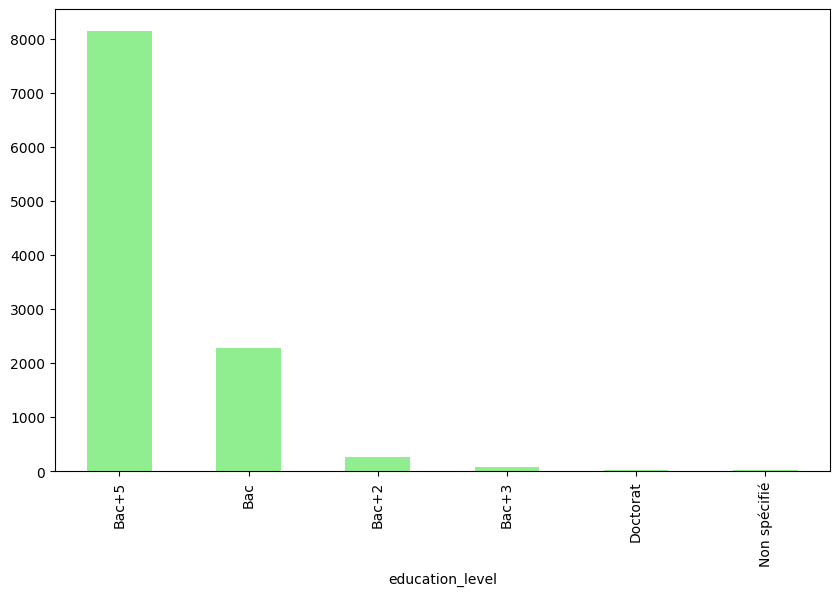

In [36]:
df_clean["education_level"].value_counts().plot(kind='bar', figsize=(10, 6), color='lightgreen')

work_mode

In [37]:
df_clean["work_mode"].value_counts()

work_mode
Télétravail    8569
Hybride        2213
Name: count, dtype: int64

<Axes: xlabel='work_mode'>

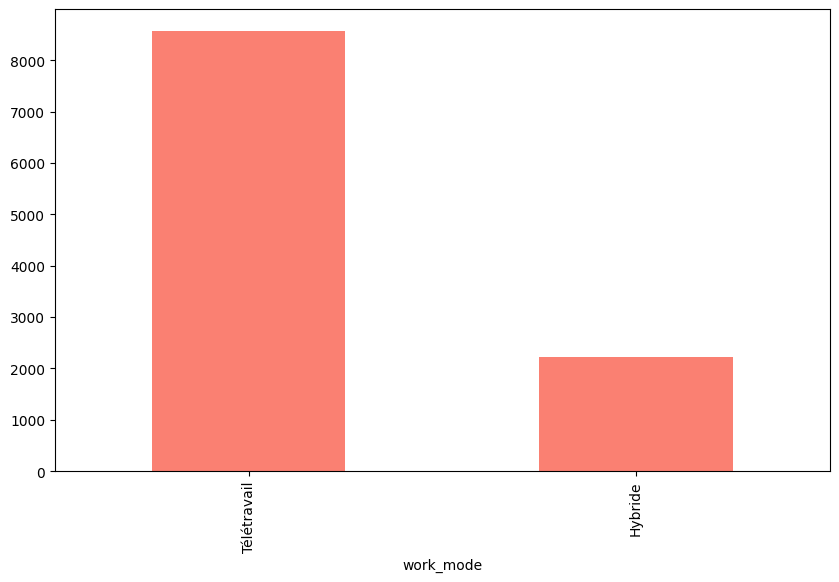

In [38]:
df_clean["work_mode"].value_counts().plot(kind='bar', figsize=(10, 6), color='salmon')

## Analyse Univariée — Continues

Expérience Min demandée f l'offre

In [39]:
df_clean["exp_years_min"].describe()

count    10782.000000
mean         3.080597
std          1.888973
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         10.000000
Name: exp_years_min, dtype: float64

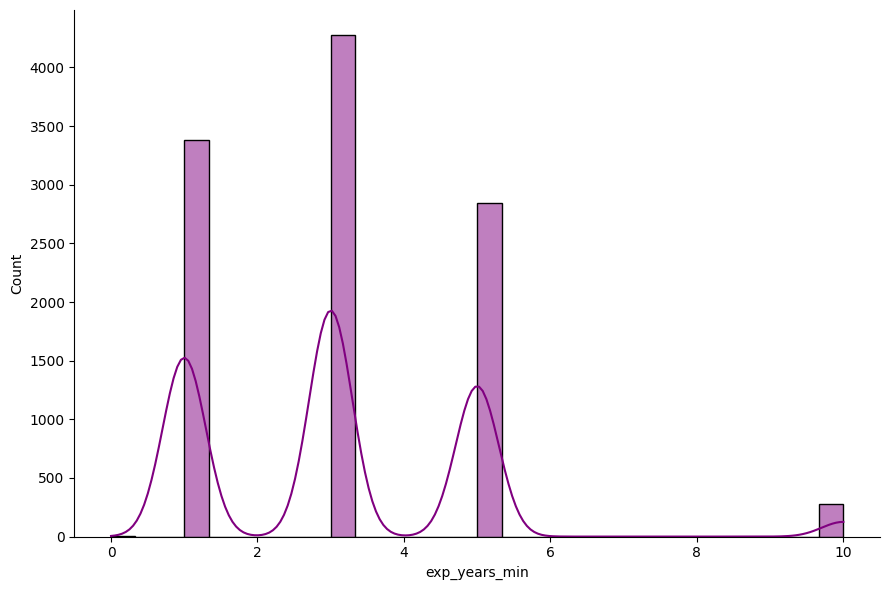

In [40]:
sns.displot(df_clean["exp_years_min"], kde=True, bins=30, color='purple', height=6, aspect=1.5)

Expérience Max demandée f l'offre

In [41]:
df_clean["exp_years_max"].describe()

count    10782.000000
mean         5.886848
std          3.744110
min          0.000000
25%          3.000000
50%          5.000000
75%         10.000000
max         20.000000
Name: exp_years_max, dtype: float64

<Axes: ylabel='exp_years_max'>

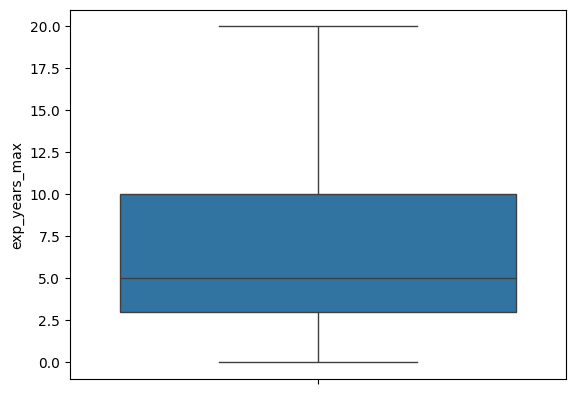

In [42]:
sns.boxplot(data=df_clean, y="exp_years_max")

<Axes: ylabel='exp_years_max'>

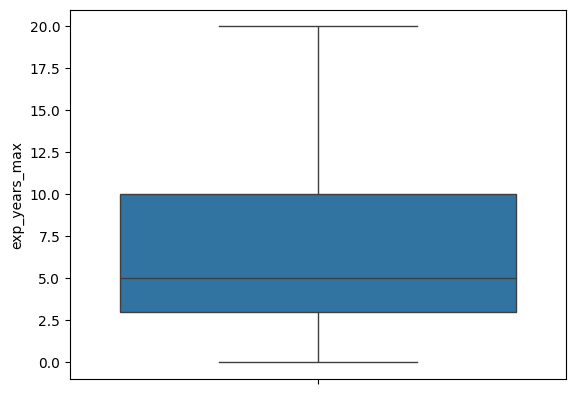

In [43]:
sns.boxplot(data=df_clean, y="exp_years_max")

# Multivariée — Discrète × Discrète

Contrat × Niveau d'Études

In [44]:
table = pd.crosstab(df_clean['contract_type'], df_clean['education_level'])
var1, var2 = 'Contrat', "Niveau d'Études"

## Multivariée — Discrète × Continue

Contrat × Expérience Min (Boxplot)

<Axes: xlabel='contract_type'>

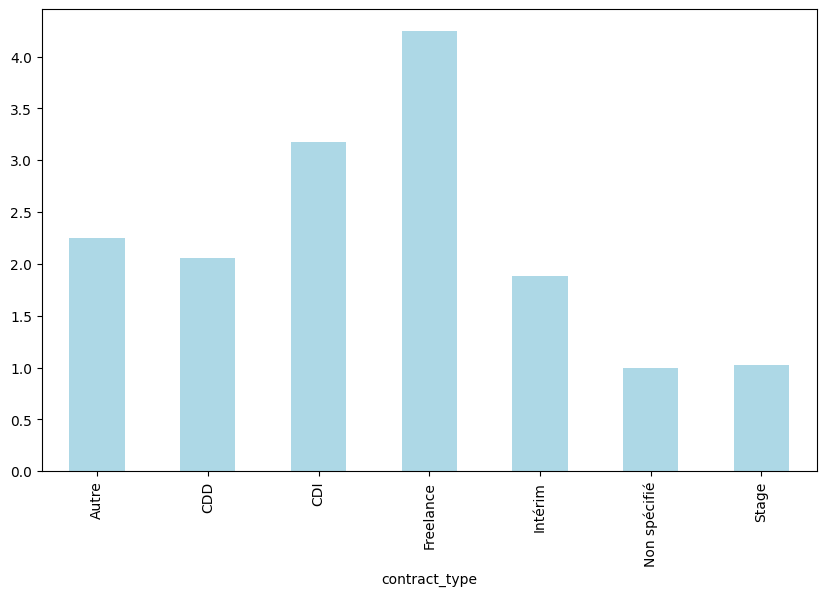

In [45]:
df_clean.groupby('contract_type')['exp_years_min'].mean().plot(kind='bar', figsize=(10, 6), color='lightblue')

Niveau d'Études × Expérience Max (Boxplot)

<Axes: xlabel='education_level'>

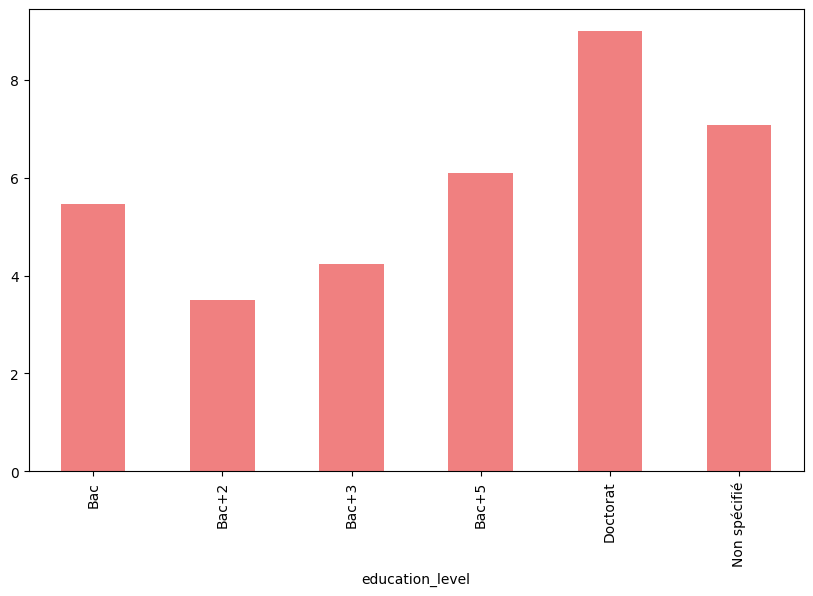

In [46]:
df_clean.groupby('education_level')['exp_years_max'].mean().plot(kind='bar', figsize=(10, 6), color='lightcoral')

Région × Expérience Min (Boxplot)

<Axes: xlabel='region'>

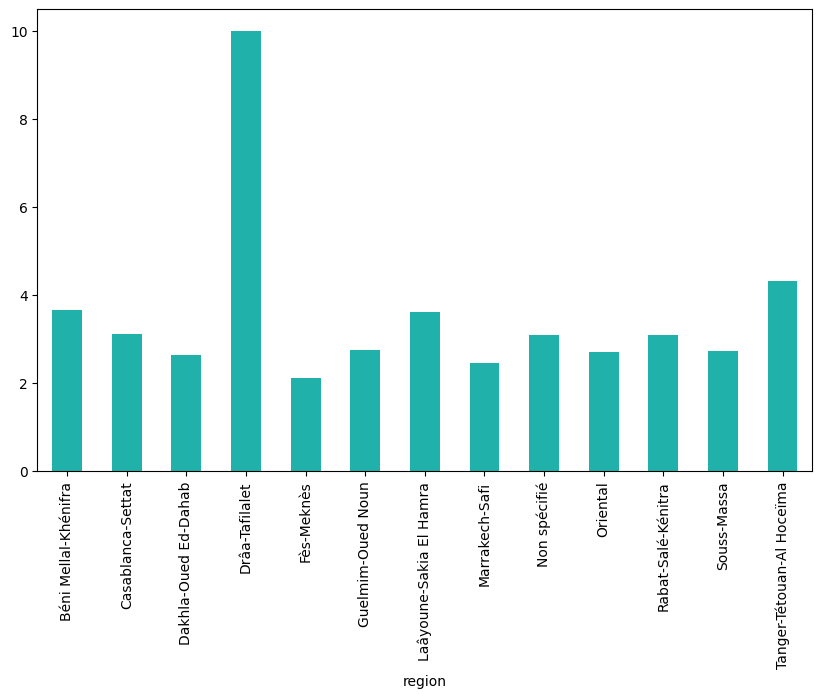

In [47]:
df_clean.groupby('region')['exp_years_min'].mean().plot(kind='bar', figsize=(10, 6), color='lightseagreen')

# Multivariée — Continue × Continue

In [48]:
df_clean = pd.read_csv("../data/clean/rekrute_clean_light.csv")

r = df['exp_years_min'].corr(df['exp_years_max'])
print(f"Corrélation: r = {r:.3f}")

sns.scatterplot(data=df_clean, x='exp_years_min', y='exp_years_max', hue='contract_type', alpha=0.6)

KeyError: 'exp_years_min'

In [ ]:
couples = df.groupby(['exp_years_min', 'exp_years_max']).size().reset_index(name='count')
couples

,exp_years_min,exp_years_max,count
0,0,0,1
1,1,1,1032
2,1,3,2350
3,3,5,4276
4,5,10,2845
5,10,20,278


In [ ]:
r = df['exp_years_min'].corr(df['exp_years_max'])
r

np.float64(0.97759264421705)

<Axes: xlabel='exp_years_min', ylabel='exp_years_max'>

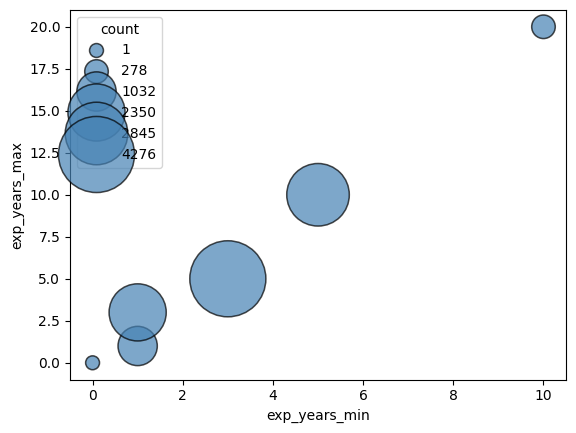

In [ ]:
sns.scatterplot(
    data=couples, 
    x='exp_years_min', 
    y='exp_years_max',
    size='count',           # TAILLE = nombre d'offres!
    sizes=(100, 3000),      # Plage de taille
    alpha=0.7,
    color='steelblue',
    edgecolor='black'
)

## Partie statistique 

test pearson

In [ ]:
from scipy import stats
import pandas as pd

# TEST DE CORRÉLATION DE PEARSON
# H0: pas de corrélation (r = 0)
# H1: il existe une corrélation (r ≠ 0)
# alpha = 0.05

df_clean = pd.read_csv("../data/clean/rekrute_clean_light.csv")
x = df_clean['exp_years_min']
y = df_clean['exp_years_max']

r, p_value = stats.pearsonr(x, y)

print(f"r = {r:.3f} | p-value = {p_value:.5f}")

if p_value < 0.05:
    print("→ On rejette H0 : corrélation significative")
else:
    print("→ On ne rejette pas H0 : pas de corrélation significative")

r = 0.978 | p-value = 0.00000
→ On rejette H0 : corrélation significative


## Interprétation du test de Pearson (exp_years_min vs exp_years_max)

**Résultat :** r = 0.978 | p-value ≈ 0.00000

On observe une corrélation **positive et très forte** entre le minimum et le 
maximum d'années d'expérience demandées dans les offres d'emploi. Le test est 
statistiquement significatif (p-value < 0.05), on rejette donc H0.

**Interprétation métier :** Ce résultat reflète une pratique implicite du marché 
marocain du recrutement : les recruteurs ne fixent pas min et max indépendamment, 
mais raisonnent en termes de **niveaux de séniorité standards** (Junior : 1-3 ans, 
Confirmé : 3-5 ans, Senior : 5-10 ans...). Une fois le niveau ciblé choisi, la 
fourchette d'expérience en découle presque automatiquement — ce qui explique 
pourquoi min et max évoluent quasi systématiquement ensemble dans le dataset.

**Limite technique :** Cette très forte corrélation signale un risque de 
**multicolinéarité** si ces deux variables sont utilisées ensemble dans un modèle 
prédictif. Il est recommandé de n'en garder qu'une seule, ou de les combiner en 
une variable synthétique (`exp_years_avg = (min + max) / 2`).

In [ ]:
from scipy import stats
import pandas as pd

# TEST DU CHI-DEUX (Chi-2) D'INDÉPENDANCE
# H0: les deux variables sont indépendantes
# H1: il existe une association entre les deux variables
# alpha = 0.05

# 1. Construire le tableau de contingence
table_contingence = pd.crosstab(df_clean['contract_type'], df_clean['work_mode'])

# 2. Test Chi-2
chi2, p_value, dof, expected = stats.chi2_contingency(table_contingence)

print(f"Chi2 = {chi2:.3f} | p-value = {p_value:.5f} | ddl = {dof}")

if p_value < 0.05:
    print("→ On rejette H0 : association significative")
else:
    print("→ On ne rejette pas H0 : pas d'association significative")

Chi2 = 86.681 | p-value = 0.00000 | ddl = 6
→ On rejette H0 : association significative


## Interprétation du test du Chi-Deux (contract_type vs work_mode)

**Résultat :** Chi2 = 86.681 | p-value ≈ 0.00000 → On rejette H0

Il existe une association significative entre le type de contrat et le mode 
de travail. Le télétravail domine largement tous les contrats (>78%), mais 
avec des écarts notables : les CDI ont la part d'hybride la plus élevée 
(~22%), tandis que les CDD (~96%) et Freelance (~88%) sont majoritairement 
en télétravail.

**Piste métier :** Les CDI, souvent liés à la production continue, gardent 
plus de présence physique ponctuelle, alors que les CDD/Freelance, liés à 
des missions ponctuelles, n'en ont pas besoin.